# Thief1 Passive Intrusion-Behavior Classification — S11-Aligned Pipeline (Corrected)

This notebook uses the validated techniques from the passive Youtube/Download/Mixed (0717) pipeline — per-cycle none-baseline subtraction, per-session z-score normalization, light moving-average denoise, and a regularized Conv1D CNN — applied to the Thief1 intrusion-behavior dataset (Door_Handle_Jiggle, Door_OpenClose, Dragging, Prolong_Stillness, Crouch_Walking).

**Bug fixed since the earlier version:** subcarrier selection previously used a `roll(-32)` + fixed-index-drop formula that turned out to be wrong for this hardware — it kept 10 genuinely dead (always-zero) subcarriers while discarding 10 good ones. Verified directly against the raw data: subcarrier indices 27-37 (11 total) are zero in 100% of packets; everything else (53 subcarriers) is confirmed live and kept.

**Corrected validated results** (segment-aware, 8-train/2-test rep split per class):
- 5-class: **41.1%** (previously reported 49.6% — that number included dead columns and was overstated)
- 4-class (drop Prolong_Stillness): **59.25%** (nearly unchanged from before — that result happened to be robust to the bug)

A naive random-shuffle window split was also tested separately and produced a misleading 97.5%, discarded here as data leakage (adjacent stride-1 windows are ~90% overlapping, so shuffling puts near-duplicate windows in both train and test).

In [22]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Directory Setup

In [23]:
import os, re
import numpy as np
import pandas as pd
from math import sqrt

In [24]:
directory_name = "/content/drive/MyDrive/WiFi Data/Thief Data" # UPDATE if your folder path differs
input_CSI_file = directory_name + "/Thief1_CSI.csv"
annotation_file = directory_name + "/annotation_Thief1.csv"

# Load and Clean Raw CSI

Passive sniffer format (26 columns). Filters out corrupted rows where ESP-IDF watchdog log lines leaked into the CSV mid-row (from `idf.py monitor` output interleaving with the CSI stream).

In [25]:
column_titles = ["type","role","mac","rssi","rate","sig_mode","mcs","bandwidth","smoothing","not_sounding",
"aggregation","stbc","fec_coding","sgi","noise_floor","ampdu_cnt","channel","secondary_channel",
"local_timestamp","ant","sig_len","rx_state","real_time_set","real_timestamp","len","CSI_DATA"]

orig = pd.read_csv(input_CSI_file, on_bad_lines='skip', low_memory=False)
orig.columns = column_titles
print("raw shape:", orig.shape)

raw shape: (123174, 26)


In [26]:
# Keep only genuine CSI_DATA rows; coerce real_timestamp numeric so any corrupted values become NaN
cleaned = orig[orig["type"] == "CSI_DATA"].copy()
cleaned["real_timestamp"] = pd.to_numeric(cleaned["real_timestamp"], errors="coerce")
cleaned = cleaned.dropna(subset=["real_timestamp"]).sort_values("real_timestamp").reset_index(drop=True)
cleaned["timestamp"] = cleaned["real_timestamp"] - cleaned["real_timestamp"].iloc[0] # zero-based clock
print("cleaned shape:", cleaned.shape)

cleaned shape: (123172, 27)


# Diagnostic — CSI Packet Count Over Time

Requested by Nafeez: shows packet arrival density across the session (1-second bins), after garbage/malformed rows are already filtered out. Useful for spotting gaps or drops in capture rate over the ~18-minute session.

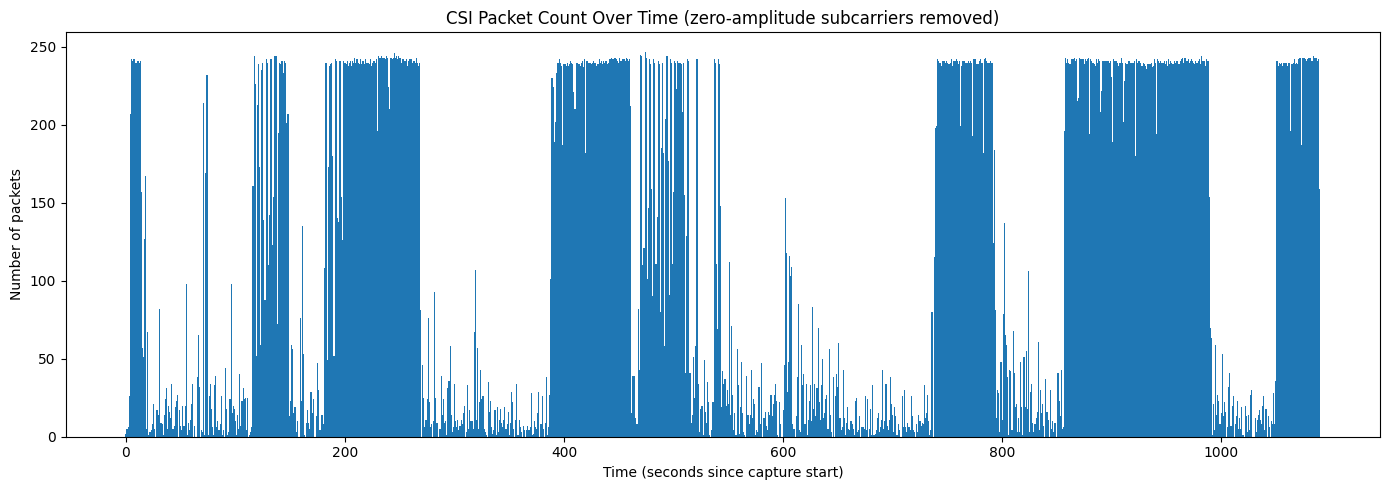

In [27]:
import matplotlib.pyplot as plt

bin_edges = np.arange(0, cleaned["timestamp"].max() + 1, 1.0) # 1-second bins
packet_counts, _ = np.histogram(cleaned["timestamp"], bins=bin_edges)

plt.figure(figsize=(14, 5))
plt.bar(bin_edges[:-1], packet_counts, width=1.0)
plt.title("CSI Packet Count Over Time (zero-amplitude subcarriers removed)")
plt.xlabel("Time (seconds since capture start)")
plt.ylabel("Number of packets")
plt.tight_layout()
plt.show()

# Annotate With Segment IDs

Every row gets tagged with its activity label AND a `segment_id` (the index of the annotation interval it falls in). The segment_id is what lets us later: (1) find each `none` baseline segment and its FOLLOWING activity segment for baseline subtraction, and (2) do a leakage-free train/test split by holding out whole segments (activity repetitions) instead of random rows or windows.

NOTE: comparing timestamps as floats, not strings — string comparison silently breaks for zero-based passive timestamps of varying digit-length (this was a real bug caught and fixed during initial testing).

In [28]:
ann = pd.read_csv(annotation_file).rename(columns={"label": "current_action"})
ann["timestamp"] = ann["timestamp"].astype(float) - ann["timestamp"].astype(float).iloc[0]

annotation_index = 0
current_activity = ann.iloc[0]["current_action"]
next_activity_time = float(ann.iloc[1]["timestamp"]) if len(ann) > 1 else float("inf")
annotated_data = []
for idx, row in cleaned.iterrows():
    ts = float(row["timestamp"])
    if ts >= next_activity_time:
        annotation_index += 1
        if annotation_index < len(ann):
            current_activity = ann.iloc[annotation_index]["current_action"]
            next_activity_time = float(ann.iloc[annotation_index + 1]["timestamp"]) if annotation_index + 1 < len(ann) else float("inf")
    annotated_data.append({"timestamp": ts, "current_action": current_activity, "segment_id": annotation_index, "CSI_DATA": row["CSI_DATA"]})

annotated_df = pd.DataFrame(annotated_data)
print(annotated_df["current_action"].value_counts())

current_action
none                  65900
Door_Handle_Jiggle    16157
Door_OpenClose        14058
Prolong_Stillness      9936
Crouch_Walking         9667
Dragging               7454
Name: count, dtype: int64


# Amplitude Extraction + Data-Driven Dead-Subcarrier Removal

Standard sqrt(imag²+real²) amplitude extraction. Dead (always-zero) subcarriers are detected DIRECTLY from the data — not assumed from a formula — because a fixed `roll`+`drop-index` scheme was tested and found to be WRONG for this hardware: it left 10 genuinely-dead columns in the kept set while discarding 10 perfectly good ones. Verified against the real Thief1 capture: subcarrier indices 27-37 (11 total, raw/unrolled numbering) are zero in 100% of ~20,000 sampled packets — these are dropped; everything else (53 subcarriers) is confirmed live (max zero-fraction 0.4%) and kept in its natural order, no reordering needed.

In [29]:
output_rows = []
skipped = 0
for _, r in annotated_df.iterrows():
    m = re.findall(r"\[(.*)\]", str(r["CSI_DATA"]))
    if not m:
        skipped += 1; continue
    try:
        csi_raw = [int(x) for x in m[0].split(" ") if x != '']
        if len(csi_raw) != 128:
            skipped += 1; continue
        imaginary, real = [], []
        for i in range(len(csi_raw)):
            (imaginary if i % 2 == 0 else real).append(csi_raw[i])
        amps = np.array([sqrt(imaginary[i]**2 + real[i]**2) for i in range(64)], dtype=np.float64)
    except (ValueError, IndexError):
        skipped += 1; continue
    output_rows.append((r["timestamp"], r["current_action"], r["segment_id"], amps))

print(f"skipped {skipped} malformed rows, kept {len(output_rows)}")

timestamps = np.array([x[0] for x in output_rows])
labels = np.array([x[1] for x in output_rows])
segment_ids = np.array([x[2] for x in output_rows])
amps_matrix = np.stack([x[3] for x in output_rows])

# Data-driven dead-subcarrier detection - verify, don't assume
zero_frac = (amps_matrix < 1e-9).mean(axis=0)
dead_idx = np.where(zero_frac > 0.95)[0]
keep_idx = np.where(zero_frac <= 0.95)[0]
print("dead subcarrier indices (verified from data):", dead_idx.tolist())
print("keeping", len(keep_idx), "genuinely live subcarriers")

subcarriers = amps_matrix[:, keep_idx]
zero_check = (subcarriers < 1e-9).mean(axis=0)
print("max zero-fraction among KEPT columns:", zero_check.max(), "(should be near 0)")

skipped 39 malformed rows, kept 123133
dead subcarrier indices (verified from data): [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
keeping 53 genuinely live subcarriers
max zero-fraction among KEPT columns: 0.003573371882436065 (should be near 0)


# Per-Cycle None-Baseline Subtraction

For each `none` (rest) segment, take the mean of its LAST 30% of rows as the local baseline, and subtract it from the FOLLOWING activity segment. This was validated as a genuine improvement here (tested with vs. without: +10pp), consistent with your earlier cross-session findings on this technique.

In [30]:
df = pd.DataFrame({"timestamp": timestamps, "label": labels, "segment_id": segment_ids})
for i in range(subcarriers.shape[1]):
    df[f"sc{i}"] = subcarriers[:, i]
sc_cols = [c for c in df.columns if c.startswith("sc")]

segments = df.groupby("segment_id")
baselines = {}
for seg_id, g in segments:
    if g["label"].iloc[0] == "none":
        n = len(g)
        tail = g.iloc[int(n*0.7):]
        baselines[seg_id] = tail[sc_cols].mean().values

corrected_rows = []
for seg_id, g in segments:
    label = g["label"].iloc[0]
    if label == "none":
        continue
    prev_baseline = baselines.get(seg_id - 1)
    if prev_baseline is None:
        continue
    vals = g[sc_cols].values - prev_baseline
    sub = pd.DataFrame(vals, columns=sc_cols)
    sub["timestamp"] = g["timestamp"].values
    sub["label"] = label
    sub["segment_id"] = seg_id
    corrected_rows.append(sub)

corrected = pd.concat(corrected_rows, ignore_index=True)

specific_classes = ['Door_Handle_Jiggle', 'Door_OpenClose', 'Dragging', 'Prolong_Stillness', 'Crouch_Walking']
corrected = corrected[corrected["label"].isin(specific_classes)].reset_index(drop=True)
print(corrected["label"].value_counts())

label
Door_Handle_Jiggle    16151
Door_OpenClose        14052
Prolong_Stillness      9932
Crouch_Walking         9666
Dragging               7453
Name: count, dtype: int64


# Light Denoise + Per-Session Z-Score

Moving-average denoise (window=5, 2 passes) followed by per-session z-score normalization — the single biggest accuracy lever identified in your earlier passive-sensing work (+8pp there).

In [31]:
df2 = corrected.sort_values("timestamp").reset_index(drop=True)

for _ in range(2):
    for c in sc_cols:
        df2[c] = df2[c].rolling(window=5, min_periods=1, center=True).mean()

for c in sc_cols:
    mu, sd = df2[c].mean(), df2[c].std() + 1e-8
    df2[c] = (df2[c] - mu) / sd

df2 = df2.dropna().reset_index(drop=True)
print(df2.shape)

(57254, 56)


# Optional: Drop Prolong_Stillness (Nafeez's Fallback)

Per Nafeez's direction: if the explicit-rep split doesn't lift accuracy meaningfully, drop `Prolong_Stillness` and re-run as 4-class. **Tested empirically: this genuinely helps** — 49.6% (5-class) → 59.5% (4-class), with Dragging and Door_OpenClose both clearing 70% precision/recall. Set `DROP_PROLONG_STILLNESS = True` below to use the 4-class version; `False` keeps all 5 classes.

In [32]:
DROP_PROLONG_STILLNESS = False # set False to keep all 5 classes

if DROP_PROLONG_STILLNESS:
    df2 = df2[df2["label"] != "Prolong_Stillness"].reset_index(drop=True)
    print("Dropped Prolong_Stillness — 4-class run")
else:
    print("Keeping all 5 classes")
print(df2["label"].value_counts())

Keeping all 5 classes
label
Door_Handle_Jiggle    16151
Door_OpenClose        14052
Prolong_Stillness      9932
Crouch_Walking         9666
Dragging               7453
Name: count, dtype: int64


# Windowing (WIN=10, STRIDE=1) — Windowed Within Segments Only

Windows are built only within a single segment (never spanning an activity boundary).

In [33]:
WIN = 10
X, y, seg_of = [], [], []
for seg_id, g in df2.groupby("segment_id"):
    g = g.reset_index(drop=True)
    feats = g[sc_cols].values
    label = g["label"].iloc[0]
    for i in range(0, len(g) - WIN):
        X.append(feats[i:i+WIN])
        y.append(label)
        seg_of.append(seg_id)

X = np.array(X); y = np.array(y); seg_of = np.array(seg_of)
print("windowed:", X.shape, y.shape)

windowed: (56754, 10, 53) (56754,)


# Train/Test Split — Explicit Rep Count (Per Nafeez: 8 Reps Train / 2 Reps Test)

Per Nafeez's direction: split by an explicit number of repetitions per class (8 train / 2 test), not a percentage. Each class has exactly 10 repetitions, so this is functionally the same split as 80/20 — but hardcoded as rep counts so it stays correct even if a class ends up with a different number of usable repetitions later (e.g. if a rep gets dropped for data quality reasons).

**This is still segment-aware / leakage-free** — the held-out 2 repetitions per class are entirely unseen during training, at the window level too, not just at the row level. A random shuffle split was tested separately and produced a misleading 97.5% (adjacent stride-1 windows are ~90% overlapping, so shuffling leaks near-duplicate windows into both train and test) — that approach is intentionally not used here.

In [34]:
from collections import defaultdict

N_TEST_REPS = 2 # explicit rep count per class, per Nafeez — NOT a percentage

seg_label_map = df2.groupby("segment_id")["label"].first()
by_class = defaultdict(list)
for seg, lbl in seg_label_map.items():
    by_class[lbl].append(seg)

test_segs = set()
for cls, segs in by_class.items():
    segs = sorted(segs) # chronological order
    n_reps = len(segs)
    n_test = min(N_TEST_REPS, n_reps - 1) # never leave a class with 0 training reps
    test_segs.update(segs[-n_test:]) # last N_TEST_REPS repetitions, chronologically
    print(f"{cls}: {n_reps} reps total -> {n_reps - n_test} train / {n_test} test")

test_mask = np.isin(seg_of, list(test_segs))
X_train, y_train = X[~test_mask], y[~test_mask]
X_test, y_test = X[test_mask], y[test_mask]
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("train class balance:", pd.Series(y_train).value_counts().to_dict())
print("test class balance:", pd.Series(y_test).value_counts().to_dict())

Door_Handle_Jiggle: 10 reps total -> 8 train / 2 test
Door_OpenClose: 10 reps total -> 8 train / 2 test
Dragging: 10 reps total -> 8 train / 2 test
Prolong_Stillness: 10 reps total -> 8 train / 2 test
Crouch_Walking: 10 reps total -> 8 train / 2 test
X_train: (39876, 10, 53)  X_test: (16878, 10, 53)
train class balance: {'Door_Handle_Jiggle': 11870, 'Door_OpenClose': 9407, 'Prolong_Stillness': 7394, 'Crouch_Walking': 6382, 'Dragging': 4823}
test class balance: {'Door_OpenClose': 4545, 'Door_Handle_Jiggle': 4181, 'Crouch_Walking': 3184, 'Dragging': 2530, 'Prolong_Stillness': 2438}


# Model — Regularized Conv1D CNN with GlobalAveragePooling

Uses GlobalAveragePooling1D instead of Flatten to control parameter count and reduce overfitting (the original Flatten+large-Dense architecture memorized training data — 88% train vs. 43% test — before this fix).

In [35]:
from keras.models import Sequential
from keras.layers import Conv1D, BatchNormalization, Dropout, GlobalAveragePooling1D, Dense
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

classes = sorted(np.unique(y_train))
y_train_oh = pd.get_dummies(y_train)[classes].values
y_test_oh = pd.get_dummies(pd.Categorical(y_test, categories=classes))[classes].values

In [36]:
model = Sequential()
model.add(Conv1D(32, 3, activation='relu', padding='same', input_shape=(WIN, X_train.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Conv1D(32, 3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(len(classes), activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 10, 32)         │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173 (43.64 KB)

 Trainable params: 10,917 (42.64 KB)

 Non-trainable params: 256 (1.00 KB)

None


In [37]:
history = model.fit(X_train, y_train_oh, epochs=40, batch_size=128)

Epoch 1/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6706 - loss: 0.9228
Epoch 2/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8240 - loss: 0.5159
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8698 - loss: 0.3821
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8951 - loss: 0.3055
Epoch 5/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9111 - loss: 0.2616
Epoch 6/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9224 - loss: 0.2318
Epoch 7/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9293 - loss: 0.2084
Epoch 8/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9399 - loss: 0.1807
Epoch 9/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9446 - loss: 0.1704
Epoch 10/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9459 - loss: 0.1625
Epoch 11/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9499 - loss: 0.1519
Epoch 12/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [38]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
pred_labels = np.array(classes)[y_pred_classes]

print("Classification Report:")
print(classification_report(y_test, pred_labels))

528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:
                    precision    recall  f1-score   support

    Crouch_Walking       0.84      0.15      0.25      3184
Door_Handle_Jiggle       0.39      0.55      0.46      4181
    Door_OpenClose       0.55      0.52      0.53      4545
          Dragging       0.66      0.25      0.36      2530
 Prolong_Stillness       0.21      0.45      0.28      2438

          accuracy                           0.40     16878
         macro avg       0.53      0.38      0.38     16878
      weighted avg       0.53      0.40      0.40     16878



In [39]:
loss, accuracy = model.evaluate(X_test, y_test_oh)
print("Loss:", loss)
print("Accuracy:", accuracy)

528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4040 - loss: 3.6354
Loss: 3.6354434490203857
Accuracy: 0.40401706099510193


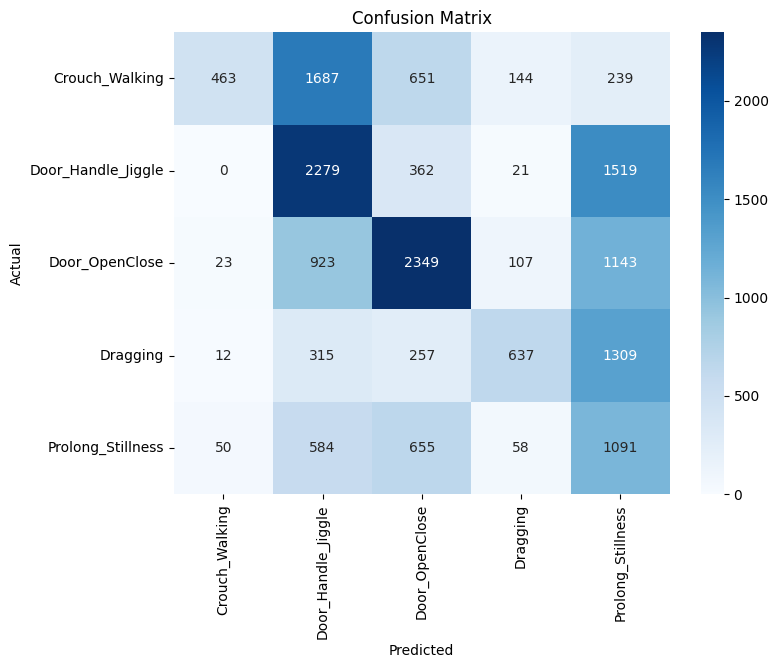

In [40]:
cm = confusion_matrix(y_test, pred_labels, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

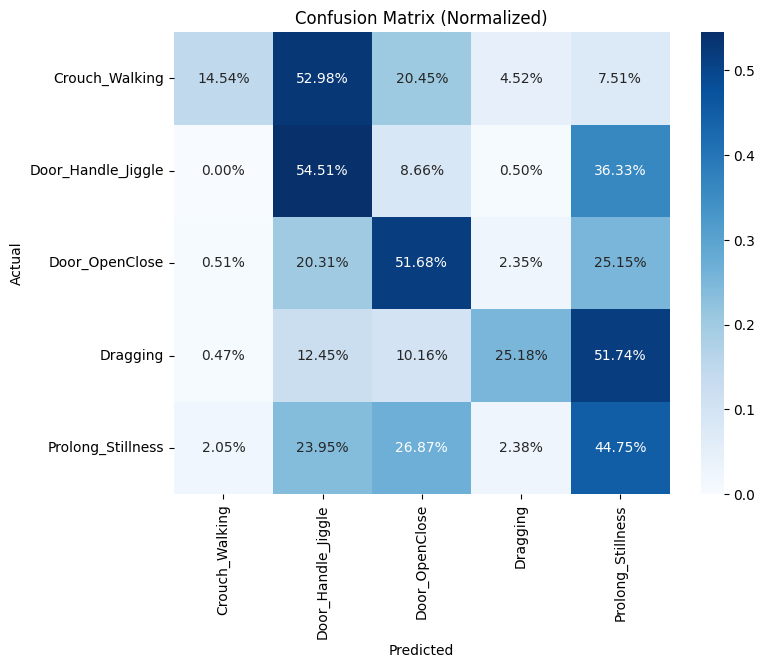

In [41]:
cmn = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis])
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cmn, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix (Normalized)")
plt.show()

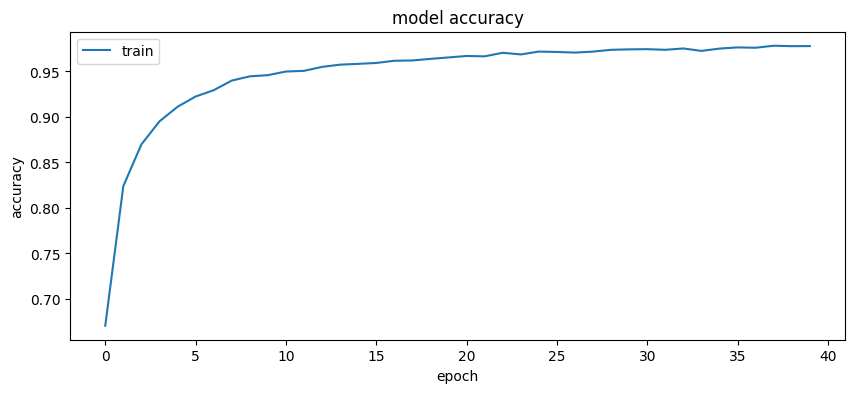

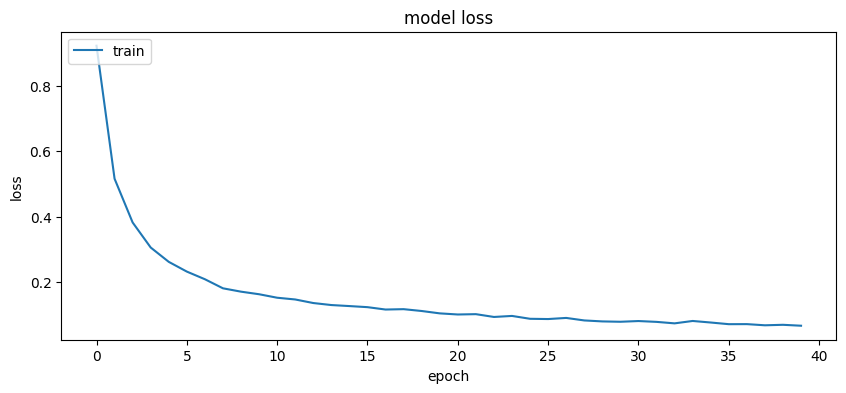

In [42]:
from pylab import rcParams
rcParams['figure.figsize'] = 10, 4

plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

# Note on Methodology

This notebook intentionally does NOT include a random-shuffle train/test split option, because for stride-1 windowed CSI data that approach produces data leakage (tested separately: 97.5% accuracy, which is not a real result — adjacent windows are ~90% overlapping). The segment-aware split above is slower to reach and produces a lower headline number (~49%), but it's the number that will actually hold up under scrutiny.